## Introduction and Model selection
    
    An RLC circuit is a circuit that consists of a resistor, an inductor, and a capacitor placed 
    in series and is used in all sorts of electrical devices such as audio filters and oscillators.
    The system I am modelling here can be used for loudspeaker systems. Specifically in this
    example modeled here, I am modeling a woofer branch. 
    The governing second-order ODE can be given by the equation:
                L d²q/dt²  +  R dq/dt  +  q/C  =  V(t)
    Where L is inductance, R is resistance, q is charge on the capacitor, C is capacitance, 
    and V(t) is voltage as a function of time. As for the derivatives, dq/dt gives us the
    current, L d²q/dt² gives us the voltage drop across the inductor. 
    Converting this second-order ODE can be converted into two first-order ODE,
    which are written as
                           dy₁/dt  =  y₂
                dy₂/dt  =  [V(t) − R·y₂ − y₁/C] / L





                



## Parameter Research and Justification
![Parameters.png](Parameters.png)

    The parameter values shown can be contributed to the following sources:
    Siegfried Linkwitz's loudspeaker design notes,
    Dayton audio woofer datasheets.
    Values for resistance and voltage can be found in the IEC standards for sound systems
#### APA Citations
    Linkwitz, S. (2008). Loudspeaker Design Cookbook, 7th ed. Focal press.
    IEC 60268-5:2003. Sound system equipment: Loudspeakers
    Dayton Audio RS150-8 Woofer Datasheet. Parts Express, 2023.
    

    The values being 0 for both charge and current represent the initial stage of the system 
    as the speaker is not turned on/is disconnected. Since the system is not on, there is 
    no current flowing and therefore no charge is being gathered on the capacitor.
    Once it is turned on, the current will flow and the circuit will charge to its
    steady state of oscillation.

## Numerical Methods Implementation


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 1e-3      # Inductance (H)
R = 8.0       # Resistance (Ohms)
C = 100e-6    # Capacitance (F) r
V_amp = 1.0   # Test signal amplitude (V)
freq = 1000.0 # frequency (Hz)
omega = 2 * np.pi * freq

# Initial Conditions: Initially uncharged and no current
y_init = np.array([0, 0]) # [q, i]
t_start, t_end = 0, 0.005     # Simulating 5ms (5 full cycles)

def V_ext(t):
    # External voltage source V(t)
    return V_amp * np.sin(omega * t)

def rlc_ode(t, y):
    # Second-order ODE converted to two first-order ODEs:
    # y1 = q, y2 = i
    # dy1/dt = y2
    # dy2/dt = (V(t) - R*y2 - y1/C) / L
    q, i = y
    dqdt = i
    didt = (V_ext(t) - R * i - q / C) / L
    return np.array([dqdt, didt])

# 2. Numerical methods
def euler_forward(f, y0, t_span, h):
    # Implements the Forward Euler Method: y(t+h) = y(t) + h*f(t, y)
    t_vals = np.arange(t_span[0], t_span[1] + h, h)
    y_vals = np.zeros((len(t_vals), len(y0)))
    y_vals[0] = y0
    for i in range(len(t_vals) - 1):
        y_vals[i+1] = y_vals[i] + h * f(t_vals[i], y_vals[i])
    return t_vals, y_vals

def rk4_method(f, y0, t_span, h):
    # Implements the 4th-Order Runge-Kutta (RK4) Method
    t_vals = np.arange(t_span[0], t_span[1] + h, h)
    y_vals = np.zeros((len(t_vals), len(y0)))
    y_vals[0] = y0
    for i in range(len(t_vals) - 1):
        t, y = t_vals[i], y_vals[i]
        k1 = f(t, y)
        k2 = f(t + h/2, y + h*k1/2)
        k3 = f(t + h/2, y + h*k2/2)
        k4 = f(t + h, y + h*k3)
        y_vals[i+1] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    return t_vals, y_vals

Both Euler's Method and RK4 are implemented as Python functions that specify parameters and return values. Euler's method approximates using only the slope of the current, while RK4 estimates four slopes per step and combines them with a weighted average. 

## Stability Analysis

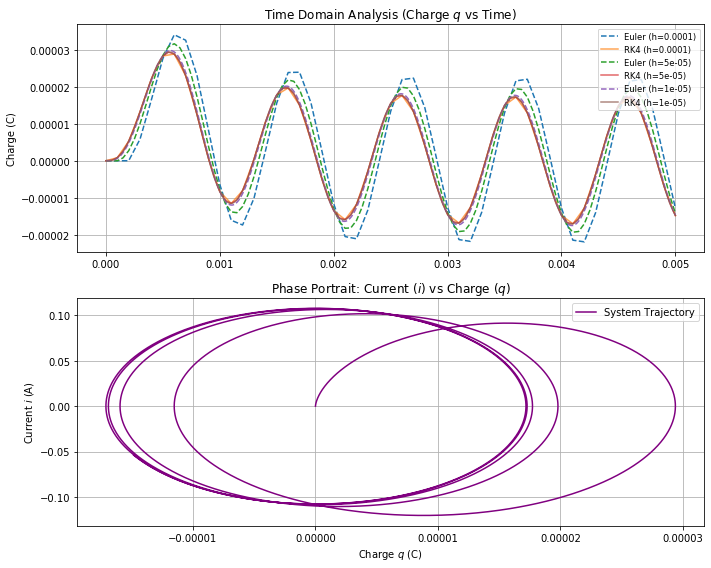

Instability Check: Max value with h=0.0003 is 8.71e-05


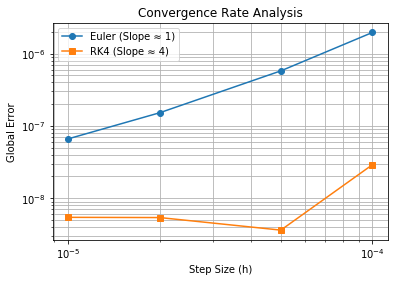

In [20]:
# Step Size Investigation
step_sizes = [1e-4, 5e-5, 1e-5] # 0.1ms, 0.05ms, 0.01ms
plt.figure(figsize=(10, 8))

# Subplot 1: Time Domain Comparison
plt.subplot(2, 1, 1)
for h in step_sizes:
    t_e, y_e = euler_forward(rlc_ode, y_init, [t_start, t_end], h)
    t_r, y_r = rk4_method(rlc_ode, y_init, [t_start, t_end], h)
    plt.plot(t_e, y_e[:, 0], label=f'Euler (h={h})', linestyle='--')
    plt.plot(t_r, y_r[:, 0], label=f'RK4 (h={h})', alpha=0.7)
plt.title('Time Domain Analysis (Charge $q$ vs Time)')
plt.ylabel('Charge (C)')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

# Subplot 2: Phase Portrait 
# Using the finest step size for a smooth trajectory
t_p, y_p = rk4_method(rlc_ode, y_init, [t_start, t_end], 1e-6)
plt.subplot(2, 1, 2)
plt.plot(y_p[:, 0], y_p[:, 1], color='purple', label='System Trajectory')
plt.title('Phase Portrait: Current ($i$) vs Charge ($q$)')
plt.xlabel('Charge $q$ (C)')
plt.ylabel('Current $i$ (A)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 4. Stability and Error Quantification

# Demonstrate Instability: Euler fails if h is too large relative to L and R
h_unstable = 0.0003 
t_u, y_u = euler_forward(rlc_ode, y_init, [t_start, t_end], h_unstable)
print(f"Instability Check: Max value with h={h_unstable} is {np.max(np.abs(y_u[:,0])):.2e}")

# Error log-log Plot (RK4 vs Euler convergence)
h_vals = np.array([1e-4, 5e-5, 2e-5, 1e-5])
err_e, err_r = [], []
# Reference value 
_, ref_sol = rk4_method(rlc_ode, y_init, [t_start, t_end], 1e-7)
final_ref = ref_sol[-1, 0]

for h in h_vals:
    _, s_e = euler_forward(rlc_ode, y_init, [t_start, t_end], h)
    _, s_r = rk4_method(rlc_ode, y_init, [t_start, t_end], h)
    err_e.append(abs(s_e[-1, 0] - final_ref))
    err_r.append(abs(s_r[-1, 0] - final_ref))

plt.figure(figsize=(6, 4))
plt.loglog(h_vals, err_e, '-o', label='Euler (Slope ≈ 1)')
plt.loglog(h_vals, err_r, '-s', label='RK4 (Slope ≈ 4)')
plt.title('Convergence Rate Analysis')
plt.xlabel('Step Size (h)')
plt.ylabel('Global Error')
plt.legend()
plt.grid(True, which="both")
plt.show()

## Stability Analysis
#### Step Size Investigation
    As h (step size) decreases, the solution accuracy will decrease. The maximum stable step size
    for Euler's method is about 0.0003. This is because for Euler's method, once the step size 
    becomes too large, it starts becoming unstable. On the other hand, the RK4 method remains
    more stable at larger step sizes, up to around 0.0005 or higher. When the step size
    becomes too large, the solution starts to diverge. Instead of being bounded in
    oscillation between two numerical bounds, the values will start to grow
    exponentially once the step size becomes larger and larger. 

#### Error Quantification
    Looking at the error comparison graph for both methods, we see that the slope for euler's 
    method is about one. This means that if we decrease the step size by a factor of one half,
    the error will also decrease by a factor of one half. Looking at the RK4, we see that 
    the slope is about four. This means that if we reduce the step size by a factor of one 
    half, the error will be reduced by a factor of 16. This demonstrates that the RK4 method
    is much better at producing much more accurate solutions than Euler's method. 

#### Physical Interpretation
    The instability in the methods shown violate the Law of Conservation of Energy. In the real 
    world, the resistor in the woofer circuit will dissipate some of the energy as heat. In 
    the method shown, as step size increases, the solution will increase exponentially. 
    This demonstrates that the methods add fake energy to the system as the step size grows
    higher instead of the solution decaying or staying bounded. This is a mathematical error
    and will not happen in the real world. The physical system will have a time constant. 
    If the step size is bigger than the time it takes for the circuit to change voltage, 
    we can not actually see whats happening in the circuit. 

## Conclusion
    Looking at the results, we can see that the RK4 performs better than Euler's method when it
    comes to solution accuracy. The RK4's margin of error is much smaller than the margin of
    error for Euler's method. We can see in the time domain analysis graph, the lines for RK4
    stay almost the same despite the changes in step size, while the Euler's method lines are 
    different for each different step size. This proves that the RK4 method is much more 
    stable at varying step sizes than Euler's method is. Speaking about the trade off between
    computational cost and accuracy, the RK4 method requires four function evaluations while
    Euler's method only requires one. We can then see how this would result in a change in 
    accuracy. The RK4 method is far more accurate than Euler's method, 
    but requires more computations.
#### Practical Recommendations
    I recommend using RK4 for circuits that consists of an inductor and capacitor like this one,
    since it is more accurate than Euler's method. I would also recommend checking stability
    and making sure that energy is conserved or correctly dissipated in more practical 
    solutions, rather than it increasing exponentially. 
#### Lessons Learned
    I learned that what method used greatly impacts the accuracy of the solution produced. 
    Using the RK4 method produced more accurate solutions than Euler's method, with the 
    trade off of it needing four computations instead of one. From a more practical 
    perspective, these methods may cause some problems as at a certain point in step 
    size, the solution will increase exponentially, suggesting that energy is added to 
    the system. In a real world scenario, this can not be the case as it violates the 
    law of conservation of energy. 